# 02 — EDA (สำรวจ data ก่อนเทรน)

**รับเข้า:** `data/clean.csv` (จาก `01_data_cleaning.ipynb`)
**ภาพทั้งหมดบันทึกที่:** `figures/02_*.png`

คำถามที่ notebook นี้ตอบ:
1. class สมดุลไหม
2. คำตอบขึ้นกับ**เครื่อง**แค่ไหน (จำนวน core, OS, VM หรือโน้ตบุ๊ก)
3. คำตอบขึ้นกับ**ประเภทงาน**แค่ไหน
4. ถ้าไม่ใช้โมเดลเลย (ใช้ mode เดียวตลอด) เสียเวลาเท่าไร → ตัวเลขที่โมเดลต้องชนะ
5. feature ไหนมีข้อมูล ตัวไหนซ้ำกัน
6. มีความเสี่ยง data leak ตรงไหน

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.feature_selection import mutual_info_classif

from helpers import (FEATURE_NAMES as F, MODES, TIME_COLS, LOG_FEATURES, COLORS, OS_COLORS,
                     INK, INK2, GRID, SURFACE, load_clean, time_lost, log_transform,
                     setup_plots, save, stacked_share)

setup_plots()
pd.set_option("display.width", 140)
df = load_clean()
times = df[TIME_COLS].to_numpy()
print(f"{len(df):,} rows | {df.machine_id.nunique()} machine settings | "
      f"{df.machine_group.nunique()} physical machines | {df.template_id.nunique()} templates | "
      f"{df.family.nunique()} families")

13,603 rows | 16 machine settings | 9 physical machines | 52 templates | 13 families


## 1. class สมดุลไหม

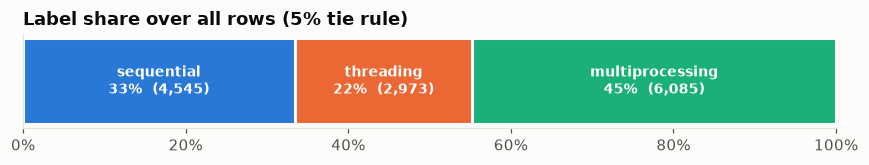

In [2]:
share = df.y.value_counts(normalize=True).loc[MODES]
fig, ax = plt.subplots(figsize=(8, 1.6))
left = 0
for m in MODES:
    ax.barh([0], [share[m]], left=left, color=COLORS[m], edgecolor=SURFACE, linewidth=2, height=0.6)
    ax.text(left + share[m] / 2, 0, f"{m}\n{share[m]:.0%}  ({(df.y == m).sum():,})",
            ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    left += share[m]
ax.set_xlim(0, 1); ax.set_yticks([]); ax.grid(False)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title("Label share over all rows (5% tie rule)")
save(fig, "02_class_balance")
plt.show()

**อ่านกราฟ:** ไม่สมดุลแต่ไม่หนักมาก (class ที่น้อยที่สุดยังมีราว 1 ใน 5) ใช้ **class weight** ตอนเทรนก็พอ ไม่ต้อง oversample

## 2. คำตอบขึ้นกับเครื่องแค่ไหน

### 2.1 แยกตามเครื่อง (เรียงตามจำนวน core)

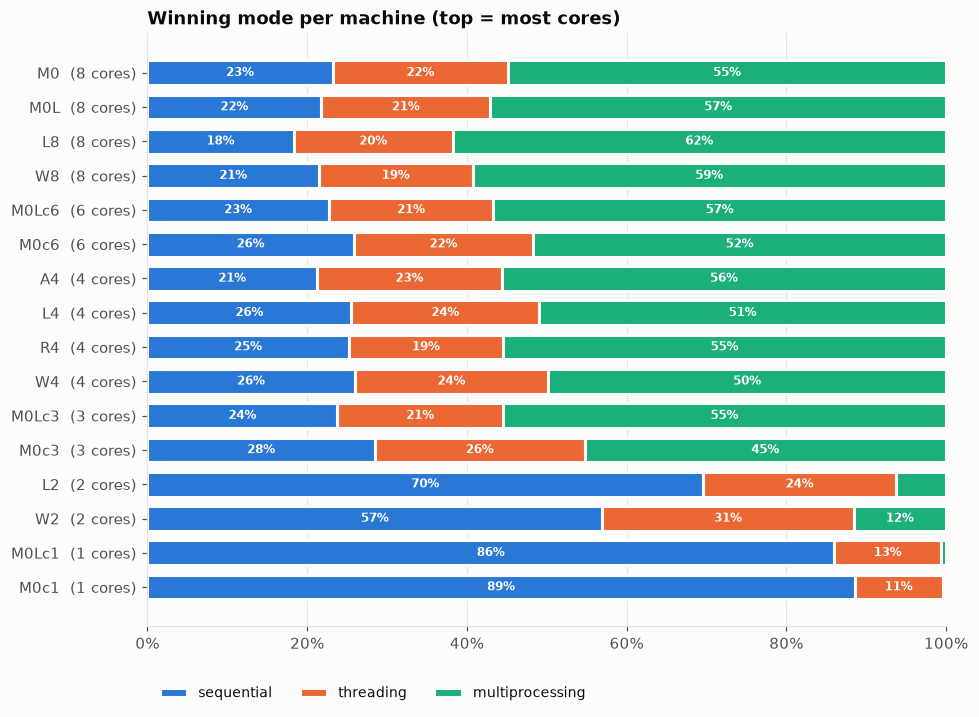

In [3]:
order = (df.groupby("machine_id")[["cpu_count"]].first()
           .assign(lap=lambda d: d.index.str.startswith("M0"))
           .sort_values(["cpu_count", "lap"], ascending=False).index)[::-1]
fig, ax = plt.subplots(figsize=(9, 6.6))
by_machine = stacked_share(ax, df, "machine_id", order=list(order))
ax.set_yticks(range(len(order)), [f"{m}  ({int(df.loc[df.machine_id == m, 'cpu_count'].iloc[0])} cores)"
                                  for m in order])
ax.set_title("Winning mode per machine (top = most cores)")
save(fig, "02_label_by_machine")
plt.show()

### 2.2 จำนวน core คือตัวแปรหลัก

แต่เครื่อง 2 core บน cloud เป็น **2 vCPU = 1 core จริง + hyperthreading** ไม่ใช่ 2 core จริง
กราฟนี้แยก VM (core = vCPU) กับโน้ตบุ๊กที่จำกัด core (core จริง)

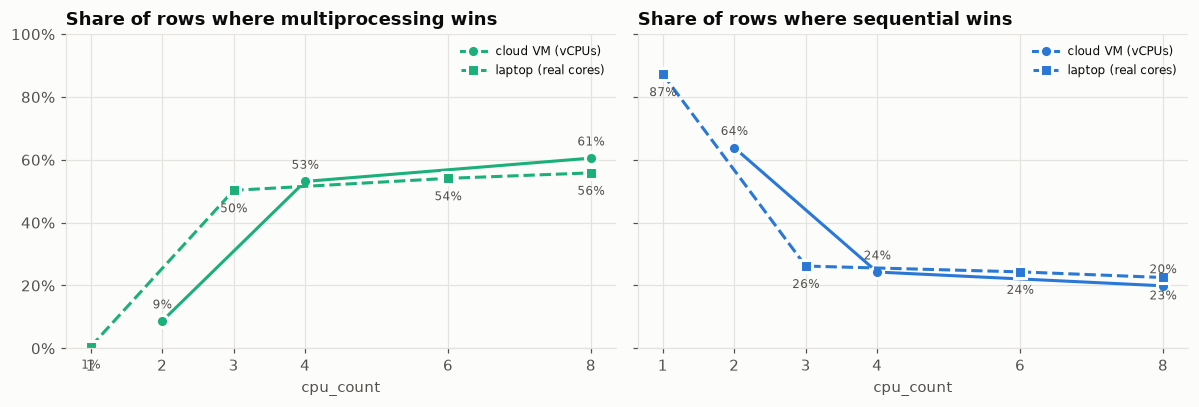

machine_id      L2  W2  L4  A4  R4  W4  M0c3  M0Lc3
cpu_count        2   2   4   4   4   4     3      3
physical_cores   1   1   2   2   4   2     4      4


In [4]:
src = np.where(df.is_laptop, "laptop (real cores)", "cloud VM (vCPUs)")
mp = (df.assign(src=src, mp=df.y.eq("multiprocessing"), seq=df.y.eq("sequential"))
        .groupby(["src", "cpu_count"])[["mp", "seq"]].mean().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, col, mode in [(axes[0], "mp", "multiprocessing"), (axes[1], "seq", "sequential")]:
    for s, style, mk, dy in [("cloud VM (vCPUs)", "-", "o", 0.04), ("laptop (real cores)", "--", "s", -0.07)]:
        d = mp[mp.src == s]
        ax.plot(d.cpu_count, d[col], style, marker=mk, ms=8, lw=2, color=COLORS[mode],
                markeredgecolor=SURFACE, markeredgewidth=2, label=s)
        for x, v in zip(d.cpu_count, d[col]):
            ax.text(x, v + dy, f"{v:.0%}", ha="center", fontsize=8, color=INK2)
    ax.set_xticks([1, 2, 3, 4, 6, 8])
    ax.set_xlabel("cpu_count")
    ax.set_title(f"Share of rows where {mode} wins")
    ax.legend(frameon=False, fontsize=8)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0].set_ylim(0, 1)
save(fig, "02_cores_vs_label")
plt.show()

print(df.groupby("machine_id")[["cpu_count", "physical_cores"]].first()
        .loc[["L2", "W2", "L4", "A4", "R4", "W4", "M0c3", "M0Lc3"]].T)

**อ่านกราฟ:**
- 1 core: multiprocessing แทบไม่เคยชนะ (ไม่มีที่ให้ขนาน)
- 2 vCPU บน cloud: multiprocessing ยังชนะน้อยมาก เพราะ L2/W2 มี **core จริงแค่ 1 core** (2 vCPU คือ hyperthread ของ core เดียว)
- ตั้งแต่ 3 core ขึ้นไป multiprocessing ชนะราวครึ่งหนึ่ง และเพิ่มช้าๆ ตามจำนวน core
- **ผลต่อโมเดล:** `cpu_count` ที่ OS รายงานไม่ได้บอกจำนวน core จริงเสมอไป โมเดลต้องอาศัย feature อื่นช่วย (เช่น `thread_probe_speedup`) และถือเป็นข้อจำกัดของระบบ

### 2.3 Windows กับ Linux (จำนวน core เท่ากัน)

ใช้คู่ที่เทียบกันได้ตรงๆ: VM ขนาดเดียวกัน และโน้ตบุ๊กเครื่องเดียวกัน (Windows กับ WSL)

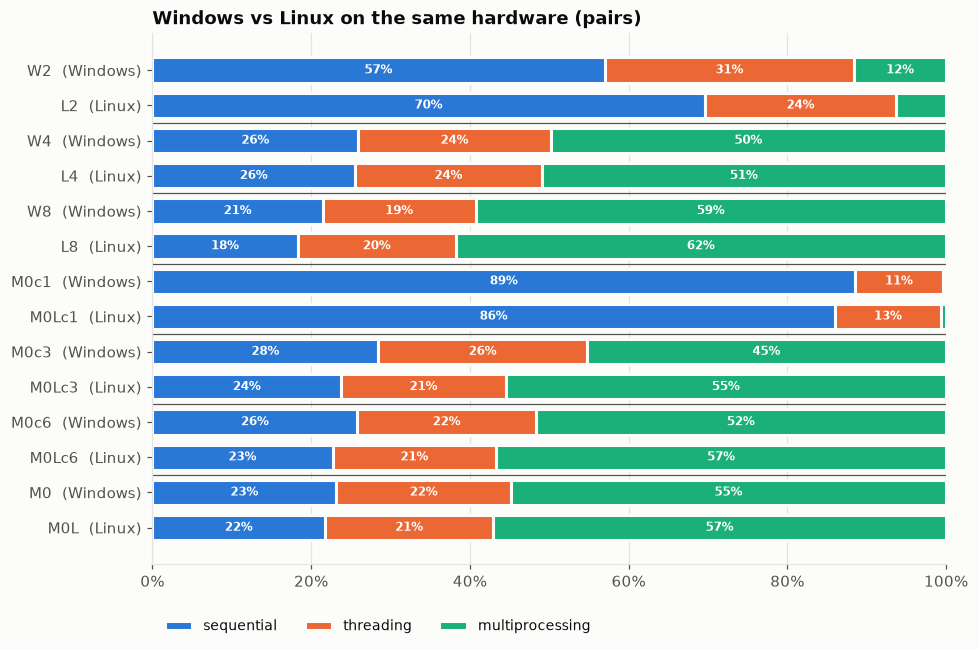

In [5]:
pairs = [("W2", "L2"), ("W4", "L4"), ("W8", "L8"), ("M0c1", "M0Lc1"), ("M0c3", "M0Lc3"),
         ("M0c6", "M0Lc6"), ("M0", "M0L")]
order = [m for p in pairs for m in p][::-1]
fig, ax = plt.subplots(figsize=(9, 6))
stacked_share(ax, df, "machine_id", order=order)
for k in range(1, len(pairs)):
    ax.axhline(2 * k - 0.5, color=INK2, lw=0.8)
ax.set_yticks(range(len(order)), [f"{m}  ({df.loc[df.machine_id == m, 'os'].iloc[0]})" for m in order])
ax.set_title("Windows vs Linux on the same hardware (pairs)")
save(fig, "02_windows_vs_linux")
plt.show()

**อ่านกราฟ:** ดูว่าในแต่ละคู่ สัดส่วนสีต่างกันแค่ไหน ถ้าต่างกันชัด แปลว่า OS มีผลจริง (เช่น Windows เปิด process ด้วย spawn ซึ่งแพงกว่า fork บน Linux)
แต่เราตั้งใจ**ไม่ใช้ `os` เป็น feature** (ไม่อยู่ใน 13 feature ที่ตกลงไว้) ผลของ OS ต้องสะท้อนผ่าน probe แทน

In [6]:
diff = []
for w, l in pairs:
    a = df[df.machine_id == w].y.value_counts(normalize=True).reindex(MODES, fill_value=0)
    b = df[df.machine_id == l].y.value_counts(normalize=True).reindex(MODES, fill_value=0)
    diff.append({"pair": f"{w} vs {l}", **{m: f"{a[m] - b[m]:+.0%}" for m in MODES}})
print("Windows minus Linux (percentage points):")
pd.DataFrame(diff).set_index("pair")

Windows minus Linux (percentage points):


,sequential,threading,multiprocessing
pair,,,
W2 vs L2,-13%,+7%,+5%
W4 vs L4,+0%,+1%,-1%
W8 vs L8,+3%,-1%,-2%
M0c1 vs M0Lc1,+3%,-2%,-0%
M0c3 vs M0Lc3,+5%,+6%,-10%
M0c6 vs M0Lc6,+3%,+2%,-5%
M0 vs M0L,+1%,+1%,-2%


## 3. คำตอบขึ้นกับประเภทงานแค่ไหน

### 3.1 แยกตาม family

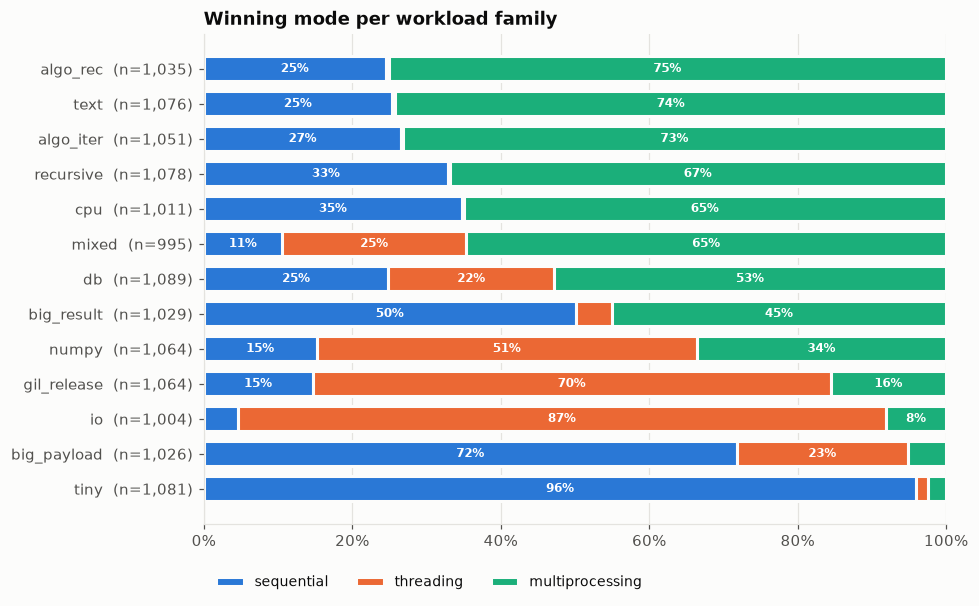

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.6))
by_family = stacked_share(ax, df, "family")
ax.set_title("Winning mode per workload family")
save(fig, "02_label_by_family")
plt.show()

### 3.2 family × จำนวน core

แต่ละช่อง = สัดส่วนที่ mode นั้นชนะ ดูว่า family เดียวกันเปลี่ยนคำตอบตามเครื่องไหม

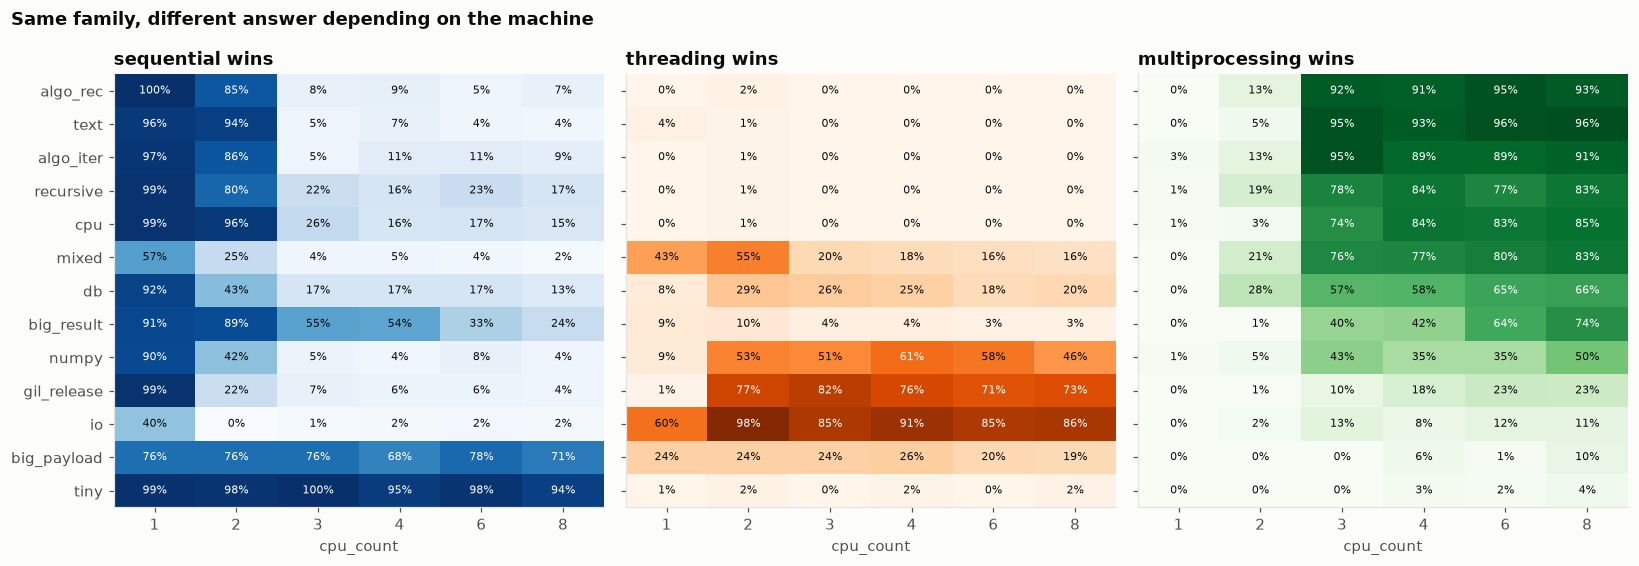

In [8]:
fams = by_family.index[::-1]
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharey=True)
cmaps = {"sequential": "Blues", "threading": "Oranges", "multiprocessing": "Greens"}
for ax, m in zip(axes, MODES):
    tab = df.assign(hit=df.y.eq(m)).pivot_table(index="family", columns="cpu_count", values="hit").loc[fams]
    im = ax.imshow(tab, cmap=cmaps[m], vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(tab.shape[1]), tab.columns)
    ax.set_yticks(range(len(fams)), fams)
    for i in range(tab.shape[0]):
        for j in range(tab.shape[1]):
            v = tab.iloc[i, j]
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=7,
                    color="white" if v > 0.6 else INK)
    ax.grid(False)
    ax.set_xlabel("cpu_count")
    ax.set_title(f"{m} wins")
fig.suptitle("Same family, different answer depending on the machine", x=0.01, ha="left", fontweight="bold")
save(fig, "02_family_x_cores")
plt.show()

### 3.3 ความยาวงานและขนาด input

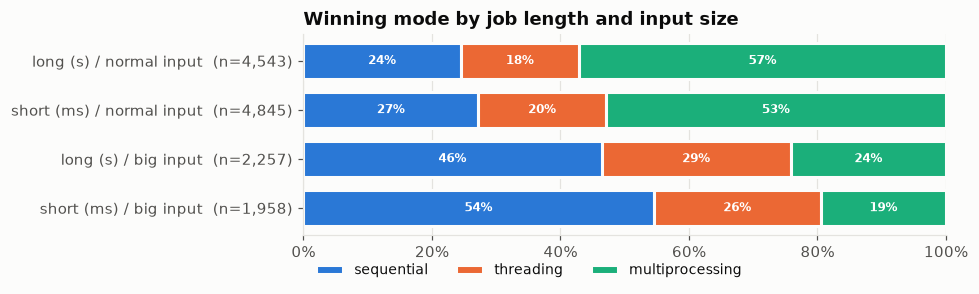

In [9]:
df["job"] = df.duration_tier.map({"ms": "short (ms)", "seconds": "long (s)"}) + " / " + df.input_tier + " input"
fig, ax = plt.subplots(figsize=(9, 2.8))
stacked_share(ax, df, "job")
ax.set_title("Winning mode by job length and input size")
save(fig, "02_label_by_job_size")
plt.show()

## 4. ถ้าไม่ใช้โมเดล เสียเวลาเท่าไร

**ตัววัดหลักของโปรเจกต์ = เวลาที่เสียไป** เทียบกับการเลือก mode ที่เร็วที่สุดถูกทุกครั้ง (รวมเวลาทุก row แล้วเทียบ งานยาวจึงมีน้ำหนักมากกว่างานสั้น)

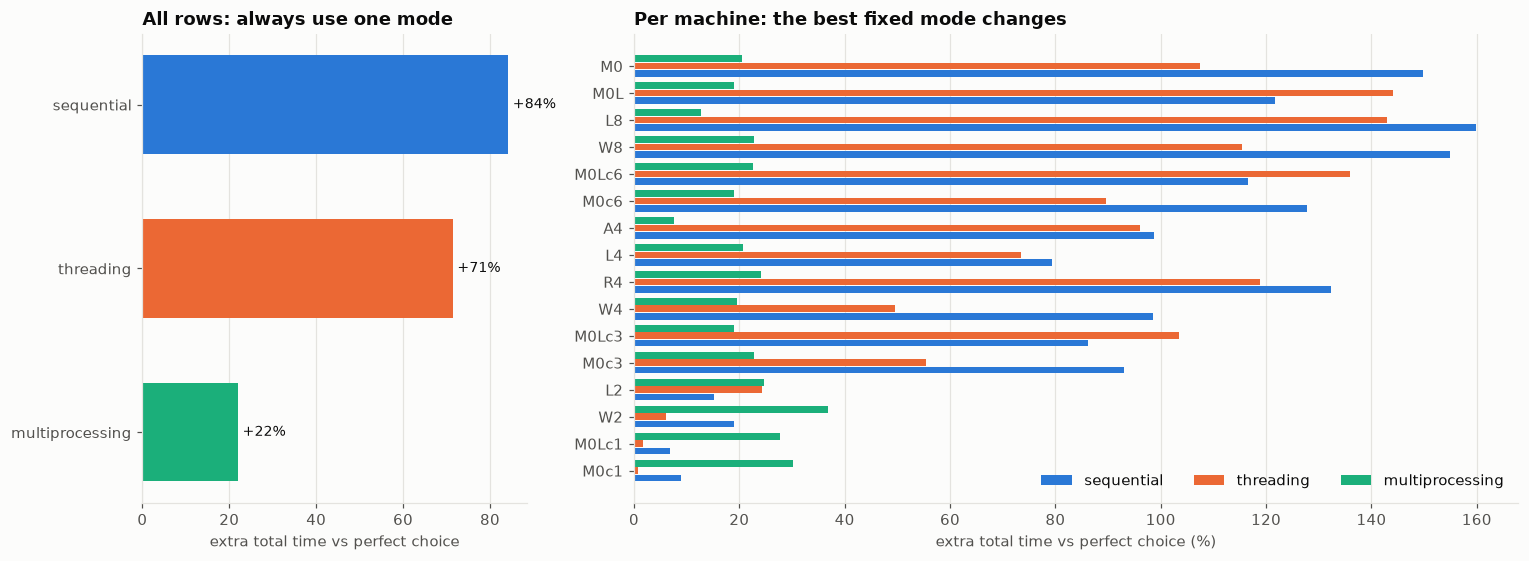

{'sequential': '+84.2%', 'threading': '+71.5%', 'multiprocessing': '+22.1%'}
best fixed mode per machine: {'A4': 'multiprocessing', 'L2': 'sequential', 'L4': 'multiprocessing', 'L8': 'multiprocessing', 'M0': 'multiprocessing', 'M0L': 'multiprocessing', 'M0Lc1': 'threading', 'M0Lc3': 'multiprocessing', 'M0Lc6': 'multiprocessing', 'M0c1': 'threading', 'M0c3': 'multiprocessing', 'M0c6': 'multiprocessing', 'R4': 'multiprocessing', 'W2': 'threading', 'W4': 'multiprocessing', 'W8': 'multiprocessing'}


In [10]:
lost = {m: time_lost(times, np.full(len(df), m)) for m in MODES}
per_machine = pd.DataFrame({m: df.groupby("machine_id").apply(
    lambda g: time_lost(g[TIME_COLS].to_numpy(), np.full(len(g), m)), include_groups=False) for m in MODES})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1, 2.3]})
ax = axes[0]
ax.barh(MODES, [lost[m] for m in MODES], color=[COLORS[m] for m in MODES], height=0.6)
for i, m in enumerate(MODES):
    ax.text(lost[m] + 1, i, f"+{lost[m]:.0f}%", va="center", fontsize=9)
ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xlabel("extra total time vs perfect choice")
ax.set_title("All rows: always use one mode")

ax = axes[1]
pm = per_machine.loc[list(by_machine.index)]
y = np.arange(len(pm))
for k, m in enumerate(MODES):
    ax.barh(y + (k - 1) * 0.27, pm[m], height=0.25, color=COLORS[m], label=m)
ax.set_yticks(y, pm.index)
ax.set_xlabel("extra total time vs perfect choice (%)")
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, ncol=3, loc="lower right")
ax.set_title("Per machine: the best fixed mode changes")
save(fig, "02_cost_of_one_mode")
plt.show()
print({m: f"+{v:.1f}%" for m, v in lost.items()})
print("best fixed mode per machine:", per_machine.idxmin(axis=1).to_dict())

**อ่านกราฟ:**
- "ใช้ multiprocessing ตลอด" คือ baseline ที่แข็งที่สุด โมเดลต้องเสียเวลา**น้อยกว่า**ตัวเลขนี้ ถึงจะมีประโยชน์
- แต่บนเครื่อง 1–2 core คำตอบตายตัวที่ดีที่สุดไม่ใช่ multiprocessing ไม่มี mode เดียวที่ชนะทุกเครื่อง → นี่คือเหตุผลที่ต้องมีตัวเลือก mode อัตโนมัติ

### 4.1 ส่วนใหญ่ตัดสินง่าย แต่มี row ที่เกือบเสมอกันจำนวนมาก

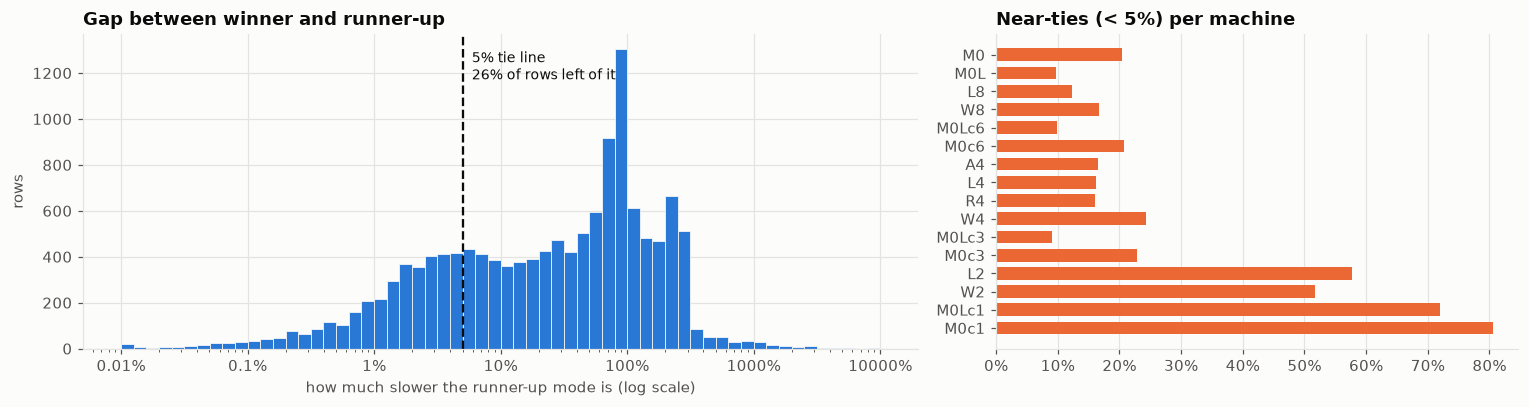

In [11]:
srt = np.sort(times, axis=1)
gap = srt[:, 1] / srt[:, 0] - 1
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
ax.hist(gap.clip(1e-4, 100), bins=np.logspace(-4, 2, 61), color=COLORS["sequential"], edgecolor=SURFACE, linewidth=0.5)
ax.axvline(0.05, color=INK, lw=1.5, ls="--")
ax.text(0.055, ax.get_ylim()[1] * 0.95, f" 5% tie line\n {np.mean(gap < 0.05):.0%} of rows left of it", fontsize=9, va="top")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v * 100:g}%"))
ax.set_xlabel("how much slower the runner-up mode is (log scale)")
ax.set_ylabel("rows")
ax.set_title("Gap between winner and runner-up")

ax = axes[1]
near = pd.Series(gap < 0.05).groupby(df.machine_id).mean().loc[list(by_machine.index)]
ax.barh(near.index, near.values, color=COLORS["threading"], height=0.7)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.grid(axis="y", visible=False)
ax.set_title("Near-ties (< 5%) per machine")
save(fig, "02_runner_up_gap")
plt.show()

## 5. feature

### 5.1 ทั้ง 13 feature แยกตาม label

feature ที่ค่ากว้างมากแสดงเป็น log10 กล่อง = ช่วง 25–75% เส้นกลาง = median

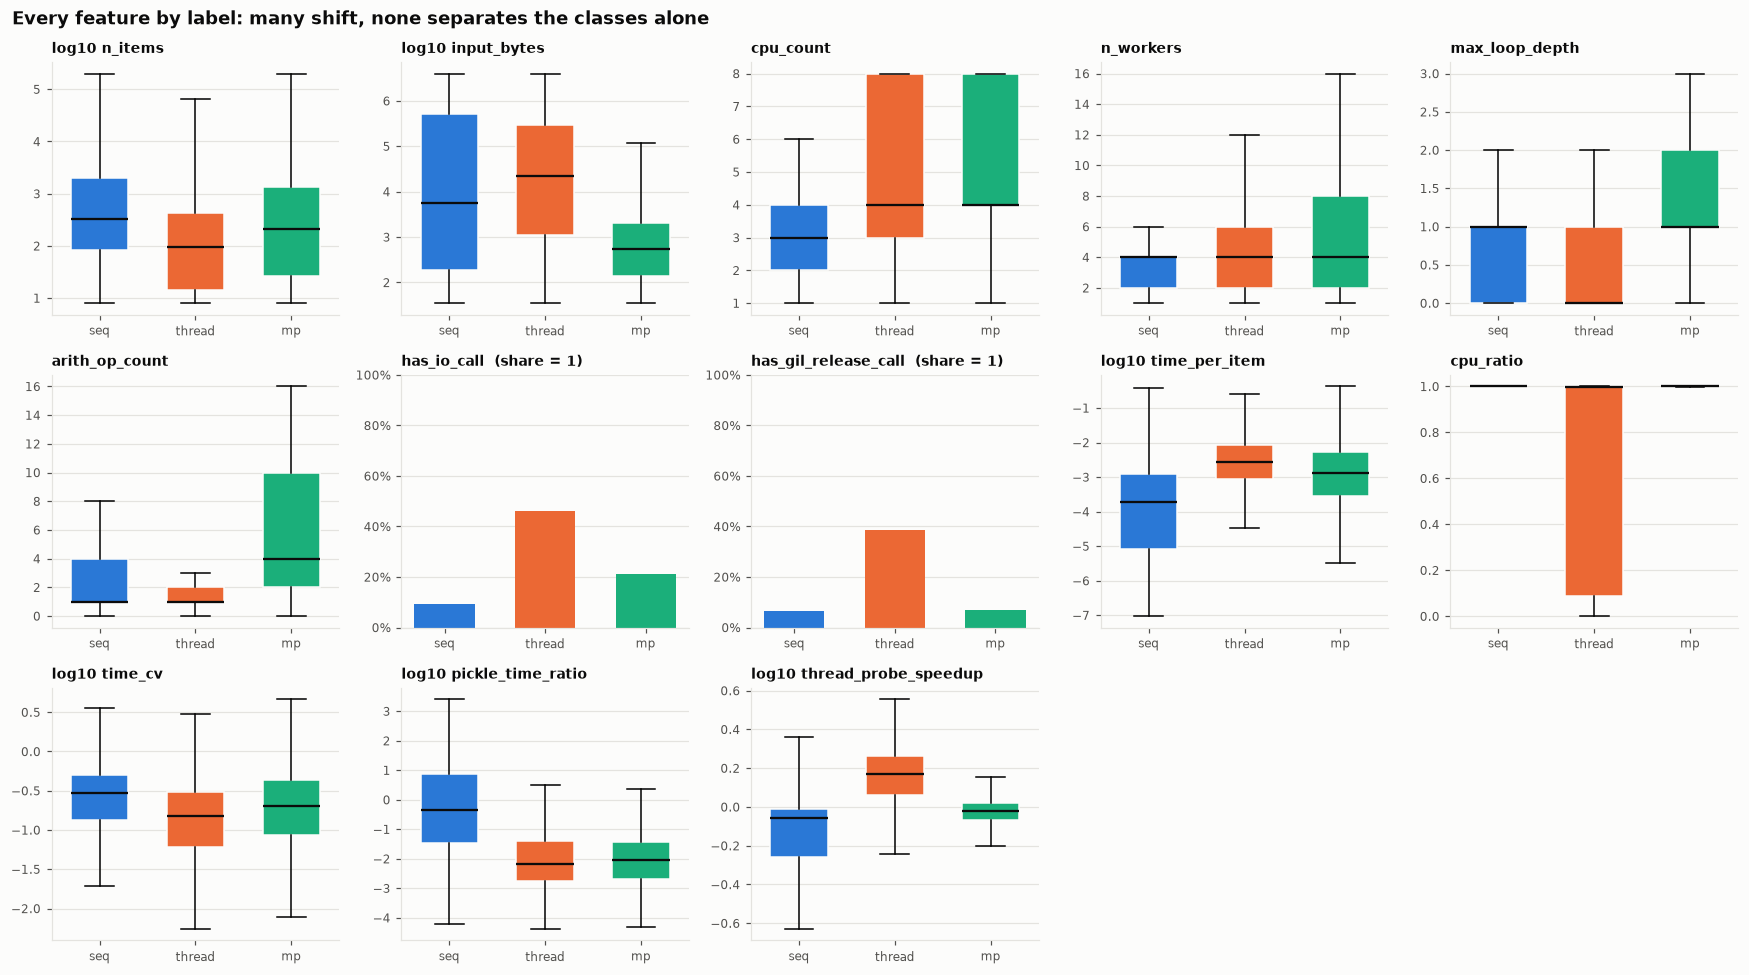

In [12]:
X = log_transform(df[F])
fig, axes = plt.subplots(3, 5, figsize=(16, 9))
for ax, f in zip(axes.flat, F):
    if df[f].nunique() <= 3:        # binary / few values -> share bars
        rate = df.groupby("y")[f].mean().loc[MODES]
        ax.bar(range(3), rate, color=[COLORS[m] for m in MODES], width=0.6)
        ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
        ax.set_title(f"{f}  (share = 1)", fontsize=9)
    else:
        data = [X.loc[df.y == m, f] for m in MODES]
        parts = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=False,
                           medianprops={"color": INK, "linewidth": 1.5})
        for p, m in zip(parts["boxes"], MODES):
            p.set_facecolor(COLORS[m]); p.set_edgecolor(SURFACE)
        ax.set_title(("log10 " if f in LOG_FEATURES else "") + f, fontsize=9)
    ax.set_xticks([0, 1, 2] if df[f].nunique() <= 3 else [1, 2, 3], ["seq", "thread", "mp"])
    ax.grid(axis="x", visible=False)
    ax.tick_params(labelsize=8)
for ax in axes.flat[len(F):]:
    ax.axis("off")
fig.suptitle("Every feature by label: many shift, none separates the classes alone",
             x=0.01, ha="left", fontweight="bold")
save(fig, "02_features_by_label")
plt.show()

### 5.2 สอง feature ที่มีข้อมูลมากที่สุดเมื่อวางคู่กัน

แต่ละจุด = 1 row (สุ่มมา 4,000 จุด) ดูว่าสีแยกกลุ่มกันได้แค่ไหน

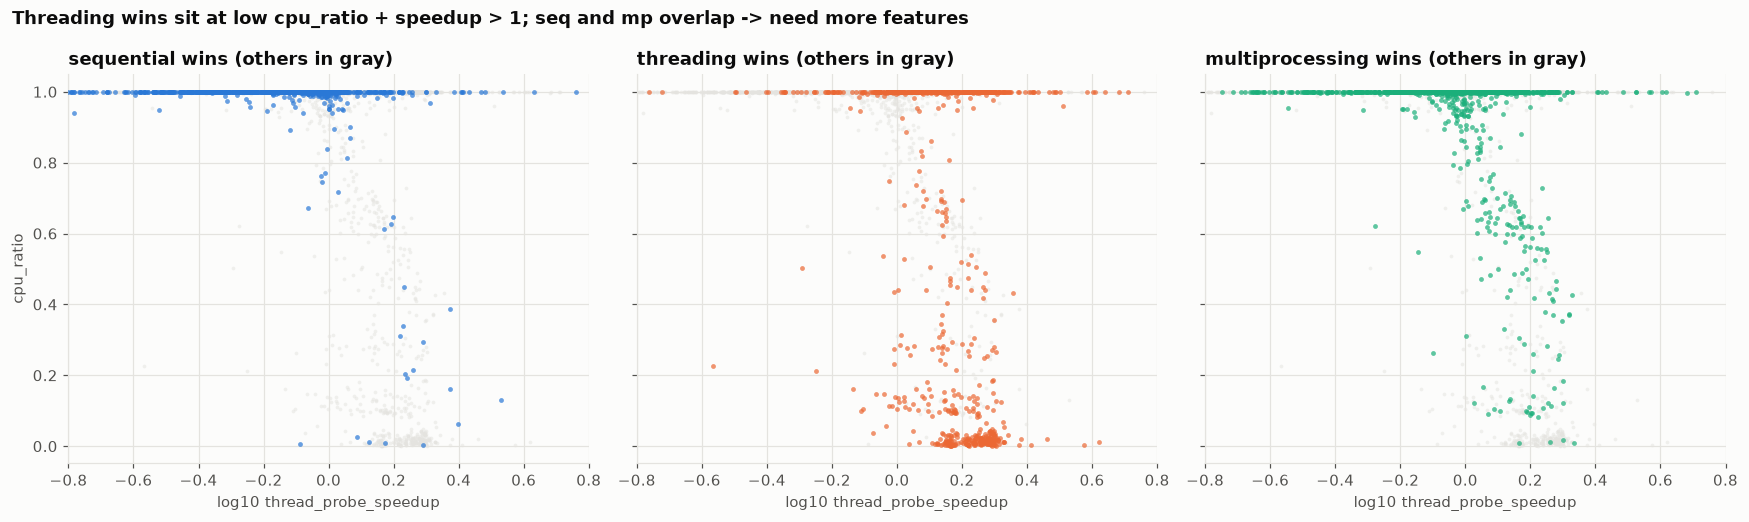

In [13]:
s = df.sample(4000, random_state=0)
Xs = log_transform(s[F])
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, m_focus in zip(axes, MODES):
    for m in MODES:
        d = Xs[s.y == m]
        focus = m == m_focus
        ax.scatter(d.thread_probe_speedup, d.cpu_ratio, s=10 if focus else 6,
                   color=COLORS[m] if focus else GRID, alpha=0.7 if focus else 0.5,
                   zorder=3 if focus else 1, label=m if focus else None, linewidths=0)
    ax.set_xlabel("log10 thread_probe_speedup")
    ax.set_title(f"{m_focus} wins (others in gray)")
    ax.set_xlim(-0.8, 0.8)
axes[0].set_ylabel("cpu_ratio")
fig.suptitle("Threading wins sit at low cpu_ratio + speedup > 1; seq and mp overlap -> need more features",
             x=0.01, ha="left", fontweight="bold")
save(fig, "02_scatter_top_features")
plt.show()

### 5.3 feature ไหนมีข้อมูลมากที่สุด (วัดทีละตัว)

mutual information = feature ตัวนี้ตัวเดียวช่วยลดความไม่แน่นอนของ label ได้แค่ไหน (0 = ไม่ช่วยเลย)

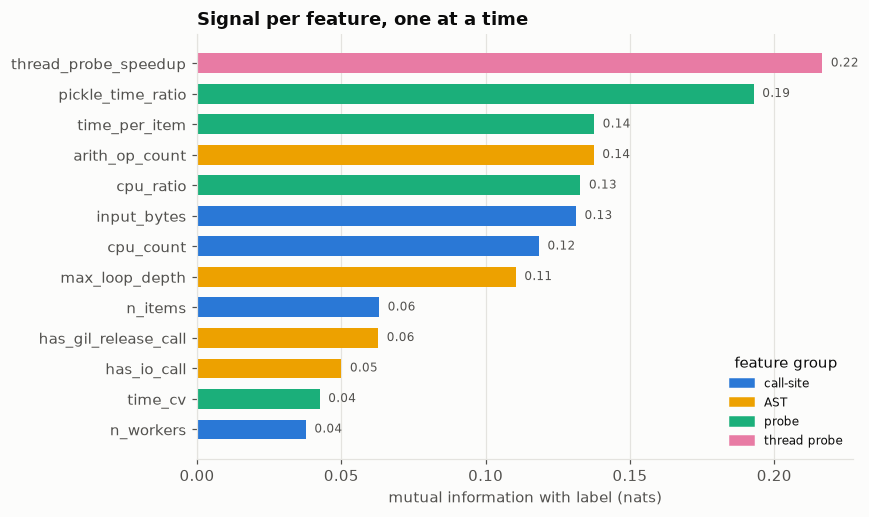

In [14]:
mi = pd.Series(mutual_info_classif(X, df.y, random_state=0), F).sort_values()
group = {f: g for g, fs in {"call-site": F[0:4], "AST": F[4:8], "probe": F[8:12], "thread probe": F[12:]}.items() for f in fs}
gcolor = {"call-site": "#2a78d6", "AST": "#eda100", "probe": "#1baf7a", "thread probe": "#e87ba4"}
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(mi.index, mi.values, color=[gcolor[group[f]] for f in mi.index], height=0.65)
for i, v in enumerate(mi.values):
    ax.text(v + 0.003, i, f"{v:.2f}", va="center", fontsize=8, color=INK2)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in gcolor.values()]
ax.legend(handles, gcolor.keys(), frameon=False, loc="lower right", title="feature group", fontsize=8)
ax.grid(axis="y", visible=False)
ax.set_xlabel("mutual information with label (nats)")
ax.set_title("Signal per feature, one at a time")
save(fig, "02_mutual_information")
plt.show()

### 5.4 feature ซ้ำกันไหม (Spearman correlation)

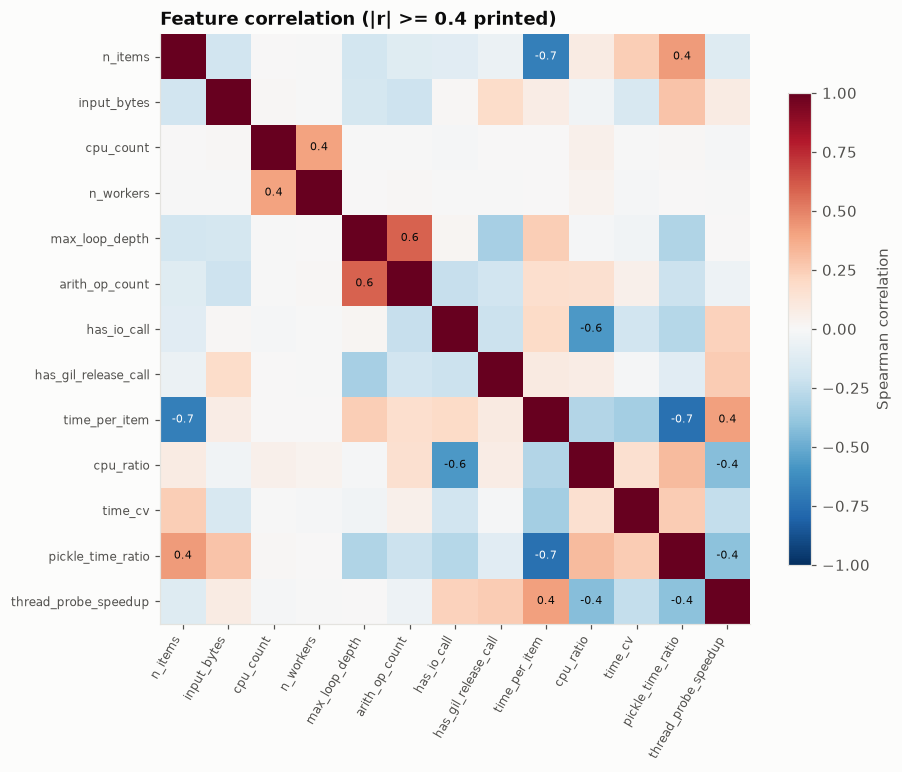

pairs with |r| > 0.6: [('n_items', 'time_per_item', np.float64(-0.68)), ('time_per_item', 'pickle_time_ratio', np.float64(-0.75))]


In [15]:
corr = df[F].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(F)), F, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(F)), F, fontsize=8)
ax.grid(False)
for i in range(len(F)):
    for j in range(len(F)):
        v = corr.iloc[i, j]
        if i != j and abs(v) >= 0.4:
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7, color="white" if abs(v) > 0.6 else INK)
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman correlation")
ax.set_title("Feature correlation (|r| >= 0.4 printed)")
save(fig, "02_feature_correlation")
plt.show()
strong = [(a, b, round(corr.loc[a, b], 2)) for i, a in enumerate(F) for b in F[i + 1:] if abs(corr.loc[a, b]) > 0.6]
print("pairs with |r| > 0.6:", strong)

## 6. ความเสี่ยง data leak

### 6.1 AST feature บอกได้ว่าเป็น template ไหน

AST feature คำนวณจากโค้ด จึงมีค่าเดียวต่อ template ถ้าสุ่มแบ่ง row ธรรมดา โมเดลจะเห็น template เดียวกันทั้งใน train และ test แล้ว "จำ" คำตอบได้

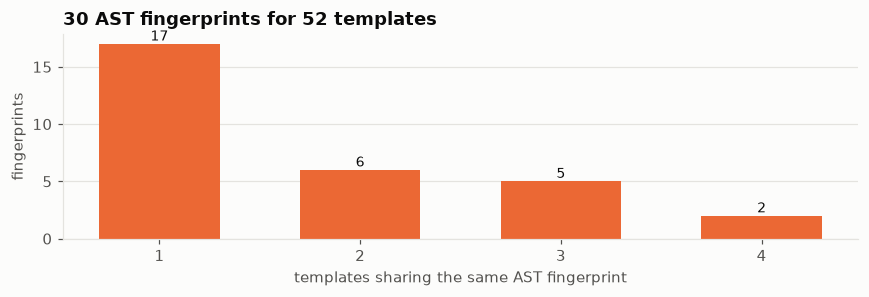

templates whose AST values change between rows: 0
templates identified uniquely by AST alone: 17


In [16]:
ast = F[4:8]
fp = df.groupby("template_id")[ast].first().astype(str).agg("|".join, axis=1)
size = fp.value_counts()
varying = int((df.groupby("template_id")[ast].nunique() > 1).any(axis=1).sum())
fig, ax = plt.subplots(figsize=(8, 2.8))
cnt = size.value_counts().sort_index()
ax.bar(cnt.index.astype(str), cnt.values, color=COLORS["threading"], width=0.6)
for x, v in zip(cnt.index.astype(str), cnt.values):
    ax.text(x, v + 0.3, str(v), ha="center", fontsize=9)
ax.set_xlabel("templates sharing the same AST fingerprint")
ax.set_ylabel("fingerprints")
ax.grid(axis="x", visible=False)
ax.set_title(f"{len(size)} AST fingerprints for {df.template_id.nunique()} templates")
save(fig, "02_ast_fingerprints")
plt.show()
print(f"templates whose AST values change between rows: {varying}")
print(f"templates identified uniquely by AST alone: {(size == 1).sum()}")

**ผลต่อการเทรน:** ต้องแบ่ง data ด้วย **GroupKFold ตาม template** (template ใน test ต้องไม่เคยเห็นตอนเทรน) และทดสอบเสริมด้วย leave-one-machine-out และ leave-one-family-out

### 6.2 มี feature ที่เฉลยคำตอบตรงๆ ไหม

ถ้ามี จะเห็นค่า mutual information สูงใกล้ค่าสูงสุด (entropy ของ label)

In [17]:
p = df.y.value_counts(normalize=True)
H = float(-(p * np.log(p)).sum())
print(f"label entropy (max possible MI): {H:.2f} nats")
print(f"highest single-feature MI: {mi.max():.2f} ({mi.idxmax()}) = {mi.max() / H:.0%} of max")
print("-> no single feature gives the answer away" if mi.max() / H < 0.5 else "-> CHECK THIS FEATURE FOR LEAKAGE")

label entropy (max possible MI): 1.06 nats
highest single-feature MI: 0.22 (thread_probe_speedup) = 20% of max
-> no single feature gives the answer away


## สรุป EDA (13,603 row, 16 ชุดเครื่อง, 4 ต.ค. 2026)

1. **class:** multiprocessing 45%, sequential 33%, threading 22% → ใช้ class weight
2. **จำนวน core สำคัญที่สุดฝั่งเครื่อง:** 1 core แทบไม่มี multiprocessing ชนะ, ตั้งแต่ 3 core ขึ้นไปชนะราวครึ่งหนึ่ง
   - VM 2 vCPU (L2/W2) มี core จริงแค่ 1 core จึงคล้ายเครื่อง 1 core มากกว่า → `cpu_count` อย่างเดียวหลอกได้
3. **Windows กับ Linux** บนเครื่องเดียวกันต่างกันไม่เกิน ~10 จุด% ไม่ต้องใช้ `os` เป็น feature
4. **family เดียวกันเปลี่ยนคำตอบตามเครื่อง:** งาน pure Python เป็น sequential บน 1–2 core แต่เป็น multiprocessing ตั้งแต่ 3 core, ส่วน `tiny` เป็น sequential ทุกเครื่อง และ `io` เป็น threading ทุกเครื่องที่มีมากกว่า 1 core
5. **ตัวเลขที่ต้องชนะ:** ใช้ multiprocessing ตลอด เสียเวลา +22% (sequential +84%, threading +72%) และ mode ตายตัวที่ดีที่สุดเปลี่ยนตามเครื่อง (1–2 core คือ sequential หรือ threading)
6. **feature:** thread_probe_speedup, pickle_time_ratio, time_per_item, arith_op_count มีข้อมูลมากที่สุด แต่ไม่มีตัวไหนตัดสินได้ตัวเดียว (สูงสุด 20% ของค่าสูงสุด) → ต้องใช้หลาย feature ร่วมกัน ซึ่งเป็นงานของโมเดล
7. **ไม่มี feature ซ้ำจนต้องตัด** (คู่ที่แรงสุด |r| = 0.75)
8. **leak:** AST มีค่าเดียวต่อ template และบอก template ได้ตรงๆ 17 จาก 52 ตัว → ต้องใช้ GroupKFold ตาม template

ถัดไป: `03_model_training.ipynb`